Необхідні бібліотеки: matplotlib, numpy, scipy, streamlit, plotly

In [ ]:
!pip install matplotlib
!pip install numpy
!pip install scipy
!pip install streamlit
!pip install plotly

**Завдання 1**

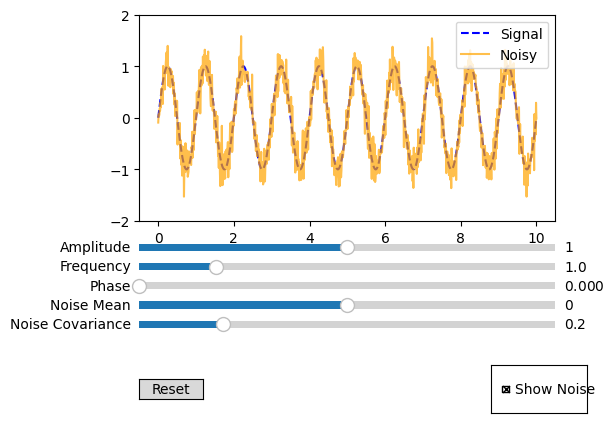

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons

x = np.linspace(0, 10, 1000)
noise_enabled = [True]
noise = np.zeros_like(x)

params = {
    "amp": 1.0,
    "freq": 1.0,
    "phase": 0.0,
    "noise_mean": 0.0,
    "noise_cov": 0.2,
    "cutoff": 5.0
}


def generate_clean():
    return params["amp"] * np.sin(2 * np.pi * params["freq"] * x + params["phase"])

def generate_noise():
    return np.random.normal(params["noise_mean"], params["noise_cov"], len(x))


fig, ax = plt.subplots()
plt.subplots_adjust(left=0.25, bottom=0.45)
ax.set_ylim(-2, 2)

line_clean, = ax.plot(x, generate_clean(), 'b--', label='Signal')
line_noisy, = ax.plot(x, generate_clean(), 'orange', label='Noisy', alpha=0.7)
ax.legend(loc="upper right", bbox_to_anchor=(1, 1))


def update_signal(val=None):
    clean = generate_clean()
    line_clean.set_ydata(clean)
    if noise_enabled[0]:
        line_noisy.set_ydata(clean + noise)
    fig.canvas.draw_idle()

def refresh_noise():
    global noise
    noise = generate_noise()
    update_signal()


def create_slider(axpos, label, valmin, valmax, valinit, callback):
    ax_slider = plt.axes(axpos)
    slider = Slider(ax_slider, label, valmin, valmax, valinit=valinit)
    slider.on_changed(callback)
    return slider

sliders = {
    "amp": create_slider([0.25, 0.38, 0.65, 0.03], 'Amplitude', 0.0, 2.0, params["amp"],
                         lambda v: update_param("amp", v)),
    "freq": create_slider([0.25, 0.34, 0.65, 0.03], 'Frequency', 0.1, 5.0, params["freq"],
                          lambda v: update_param("freq", v)),
    "phase": create_slider([0.25, 0.30, 0.65, 0.03], 'Phase', 0.0, 2*np.pi, params["phase"],
                           lambda v: update_param("phase", v)),
    "noise_mean": create_slider([0.25, 0.26, 0.65, 0.03], 'Noise Mean', -1.0, 1.0, params["noise_mean"],
                                lambda v: update_param("noise_mean", v, noise=True)),
    "noise_cov": create_slider([0.25, 0.22, 0.65, 0.03], 'Noise Covariance', 0.0, 1.0, params["noise_cov"],
                               lambda v: update_param("noise_cov", v, noise=True))
}

def update_param(name, value, noise=False):
    params[name] = value
    if noise:
        refresh_noise()
    else:
        update_signal()


reset_ax = plt.axes([0.25, 0.08, 0.1, 0.04])
button = Button(reset_ax, 'Reset')
def reset(event):
    for key, slider in sliders.items():
        slider.reset()
    refresh_noise()
button.on_clicked(reset)

check_ax = plt.axes([0.8, 0.05, 0.15, 0.1])
check = CheckButtons(check_ax, ['Show Noise'], [True])
def toggle_noise(label):
    noise_enabled[0] = not noise_enabled[0]
    line_noisy.set_visible(noise_enabled[0])
    refresh_noise() if noise_enabled[0] else update_signal()
check.on_clicked(toggle_noise)

refresh_noise()
plt.show()


Дана програма генерує графік гармоніки з накладеним шумом. Програма є інтерактивною та дозволяє налаштувовувати параметри гармоніки, такі як амплітуда, частота, фаза, а також середнє значення шуму та дисперсію. Шум та гармоніка оброблюються окремо.

Було використано numpy для математичних функцій, а також matplotlib для побудови графіку та для створення інтерфейсу.

**Завдання 2**

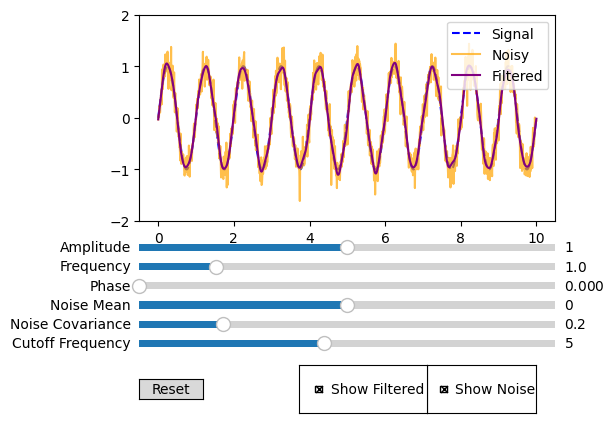

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import iirfilter, filtfilt

x = np.linspace(0, 10, 1000)
noise_enabled = [True]
filter_enabled = [True]
noise = np.zeros_like(x)

params = {
    "amp": 1.0,
    "freq": 1.0,
    "phase": 0.0,
    "noise_mean": 0.0,
    "noise_cov": 0.2,
    "cutoff": 5.0
}


def generate_clean():
    return params["amp"] * np.sin(2 * np.pi * params["freq"] * x + params["phase"])

def generate_noise():
    return np.random.normal(params["noise_mean"], params["noise_cov"], len(x))

def apply_filter(signal):
    b, a = iirfilter(
        N=4,
        Wn=params["cutoff"],
        btype='low',
        ftype='butter',
        fs=100 
    )
    return filtfilt(b, a, signal)



fig, ax = plt.subplots()
plt.subplots_adjust(left=0.25, bottom=0.45)
ax.set_ylim(-2, 2)

line_clean, = ax.plot(x, generate_clean(), 'b--', label='Signal')
line_noisy, = ax.plot(x, generate_clean(), 'orange', label='Noisy', alpha=0.7)
line_filtered, = ax.plot(x, generate_clean(), 'purple', label='Filtered')
ax.legend(loc="upper right", bbox_to_anchor=(1, 1))


def update_signal(val=None):
    clean = generate_clean()
    line_clean.set_ydata(clean)
    if noise_enabled[0]:
        line_noisy.set_ydata(clean + noise)
        line_filtered.set_ydata(apply_filter(clean + noise))
    fig.canvas.draw_idle()

def refresh_noise():
    global noise
    noise = generate_noise()
    update_signal()


def create_slider(axpos, label, valmin, valmax, valinit, callback):
    ax_slider = plt.axes(axpos)
    slider = Slider(ax_slider, label, valmin, valmax, valinit=valinit)
    slider.on_changed(callback)
    return slider

sliders = {
    "amp": create_slider([0.25, 0.38, 0.65, 0.03], 'Amplitude', 0.0, 2.0, params["amp"],
                         lambda v: update_param("amp", v)),
    "freq": create_slider([0.25, 0.34, 0.65, 0.03], 'Frequency', 0.1, 5.0, params["freq"],
                          lambda v: update_param("freq", v)),
    "phase": create_slider([0.25, 0.30, 0.65, 0.03], 'Phase', 0.0, 2*np.pi, params["phase"],
                           lambda v: update_param("phase", v)),
    "noise_mean": create_slider([0.25, 0.26, 0.65, 0.03], 'Noise Mean', -1.0, 1.0, params["noise_mean"],
                                lambda v: update_param("noise_mean", v, noise=True)),
    "noise_cov": create_slider([0.25, 0.22, 0.65, 0.03], 'Noise Covariance', 0.0, 1.0, params["noise_cov"],
                               lambda v: update_param("noise_cov", v, noise=True)),
    "cutoff": create_slider([0.25, 0.18, 0.65, 0.03], 'Cutoff Frequency', 1.0, 10.0, params["cutoff"],
                            lambda v: update_param("cutoff", v))
}

def update_param(name, value, noise=False):
    params[name] = value
    if noise:
        refresh_noise()
    else:
        update_signal()


reset_ax = plt.axes([0.25, 0.08, 0.1, 0.04])
button = Button(reset_ax, 'Reset')
def reset(event):
    for key, slider in sliders.items():
        slider.reset()
    refresh_noise()
button.on_clicked(reset)

check_ax = plt.axes([0.7, 0.05, 0.17, 0.1])
check = CheckButtons(check_ax, ['Show Noise'], [True])

filter_check_ax = plt.axes([0.5, 0.05, 0.20, 0.1])
filter_check = CheckButtons(filter_check_ax, ['Show Filtered'], [True])
def toggle_noise(label):
    noise_enabled[0] = not noise_enabled[0]
    line_noisy.set_visible(noise_enabled[0])
    line_filtered.set_visible(noise_enabled[0])
    refresh_noise() if noise_enabled[0] else update_signal()

def toggle_filtered(label):
    filter_enabled[0] = not filter_enabled[0]
    line_filtered.set_visible(filter_enabled[0])
    update_signal()

check.on_clicked(toggle_noise)
filter_check.on_clicked(toggle_filtered)

refresh_noise()
plt.show()


До попередньої програми було додано фільтрацію шуму за наближенням до гармоніки та відповідні налаштування для неї

**Завдання 3**
Використано візуальну бібліотеку plotly з бібліотекою streamlit
Було реалізовано фільтр на основі адаптивного коефіцієнту

In [ ]:
import streamlit as st
import numpy as np
import plotly.graph_objects as go

GRAPH_HEIGHT_PX = 500

st.title("Signal Generator with Noise")
col1, col2 = st.columns([1,4])

@st.cache_data
def generate_noise(mean, cov, size):
    return np.random.normal(mean, cov, size)

def generate_clean(x, amp, freq, phase):
    return amp * np.sin(2 * np.pi * freq * x + phase)

def easy_mean(signal: np.ndarray, s_k=0.2, max_k=0.9, d=1.5) -> np.ndarray:
    filtered = np.zeros_like(signal)
    filtered[0] = signal[0]
    for i in range(1, len(signal)):
        diff = signal[i] - filtered[i-1]
        k = s_k if abs(diff) < d else max_k
        filtered[i] = filtered[i-1] + diff * k
    return filtered

x = np.linspace(0, 10, 1000)

with col1:
    amp = st.slider("Amplitude", 0.0, 2.0, 1.0, 0.01)
    freq = st.slider("Frequency", 0.1, 5.0, 1.0, 0.01)
    phase = st.slider("Phase", 0.0, 2*np.pi, 0.0, 0.01)
    noise_mean = st.slider("Noise Mean", -1.0, 1.0, 0.0, 0.01)
    noise_cov = st.slider("Noise Covariance", 0.0, 1.0, 0.2, 0.01)
    show_noise = st.checkbox("Show Noise", value=True)

clean_signal = generate_clean(x, amp, freq, phase)
noise = generate_noise(noise_mean, noise_cov, len(x))
noisy_signal = clean_signal + noise
filtered_signal = easy_mean(noisy_signal)

with col2:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=clean_signal, mode='lines', name='Clean Signal',
                            line=dict(color='blue', dash='dash')))
    if show_noise:
        fig.add_trace(go.Scatter(x=x, y=noisy_signal, mode='lines', name='Noisy Signal',
                                line=dict(color='orange')))
        fig.add_trace(go.Scatter(x=x, y=filtered_signal, mode='lines', name='Filtered Signal',
                                line=dict(color='purple')))
        
    fig.update_layout(
        title="Signal Visualization",
        height=GRAPH_HEIGHT_PX,
        margin=dict(l=20, r=20, t=40, b=20),
        xaxis=dict(fixedrange=True),
        yaxis=dict(fixedrange=True)
    )

    st.plotly_chart(fig, use_container_width=True)

In [7]:
!streamlit run Lab5full3.py

^C
